In [1]:
import warnings
import matplotlib.pyplot as plt
import named_arrays as na
import esis

In [2]:
warnings.filterwarnings("ignore")

In [3]:
axis_time = "time"

In [4]:
axis_transition = "transition"

In [5]:
axis_velocity = "velocity"

In [6]:
axis_x = "detector_x"
axis_y = "detector_y"

In [7]:
scene = esis.flights.f1.data.synth.scene_aia(
    axis_time=axis_time,
    axis_detector_x=axis_x,
    axis_detector_y=axis_y,
    axis_wavelength=axis_transition,
    axis_velocity=axis_velocity,
    limit=1,
)

In [8]:
instrument = esis.flights.f1.optics.design_single(num_distribution=0)

In [9]:
instrument.pupil.num = 2

In [10]:
sensor = instrument.camera.sensor
sensor.width_pixel = 2 * sensor.width_pixel
sensor.num_pixel_x = sensor.num_pixel_x // 2
sensor.num_pixel_y = sensor.num_pixel_y // 2

In [11]:
%%time
images = instrument.system.image(
    scene=scene[{axis_time: 0}],
    axis_wavelength=axis_velocity,
    axis_field=(axis_x, axis_y),
)

CPU times: user 1min 19s, sys: 25.8 s, total: 1min 45s
Wall time: 1min 34s


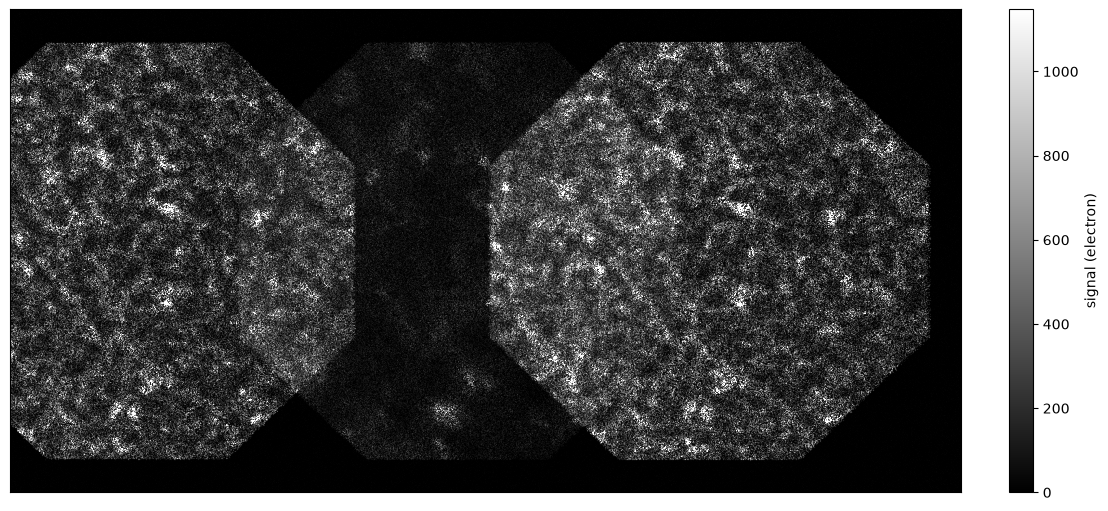

In [12]:
fig, ax = plt.subplots(
    figsize=(11, 5),
    constrained_layout=True,
)
vmax = images.outputs.percentile(99.9).value
img = na.plt.pcolormesh(
    images.inputs.position.x,
    images.inputs.position.y,
    C=images.outputs.sum(axis_transition).value,
    cmap="gray",
    vmin=0,
    vmax=vmax,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(img.ndarray.item(), label=f"signal ({images.outputs.unit})");